# Mode 02 local/modular: Z24 dataset.zip — 1DCNN-LSTM-ResNet

This notebook is the local workflow for `raw_data/dataset.zip`. Run it with the working directory inside this project (for example `notebooks/modes02/local`). It keeps all ten segments from one inferred condition/setup recording in the same split and uses the standard Keras layout `(time samples, sensors)`.

In [4]:
from pathlib import Path
from datetime import datetime
import json
import sys

start = Path.cwd().resolve()
ROOT = next((p for p in (start, *start.parents) if (p / 'src' / 'data' / 'z24_dataset_zip.py').exists()), None)
if ROOT is None:
    raise FileNotFoundError('Run this notebook with its working directory inside the shm project (for example notebooks/modes02/local)')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix

from src.data.z24_dataset_zip import (
    load_dataset_arrays, materialize_split, normalize_from_train,
    prepare_dataset_zip, split_by_setup,
)
from src.models.dcnn_lstm_resnet import build_model

print('Project root:', ROOT)
print('TensorFlow:', tf.__version__)
print('GPU devices:', tf.config.list_physical_devices('GPU'))


[TensorFlow DLL Diagnostic] Analyzing: c:\Users\phuotran\Data\research\shm\.venv\Lib\site-packages\tensorflow\python\_pywrap_tensorflow_internal.pyd
[Error] Failed to load _pywrap_tensorflow_common.dll: ACCESS DENIED (0x05) - Check file permissions.


ImportError: Traceback (most recent call last):
  File "c:\Users\phuotran\Data\research\shm\.venv\Lib\site-packages\tensorflow\python\pywrap_tensorflow.py", line 74, in <module>
    from tensorflow.python._pywrap_tensorflow_internal import *
ImportError: DLL load failed while importing _pywrap_tensorflow_internal: Access is denied.


Failed to load the native TensorFlow runtime.
See https://www.tensorflow.org/install/errors for some common causes and solutions.
If you need help, create an issue at https://github.com/tensorflow/tensorflow/issues and include the entire stack trace above this error message.

## Configuration

In [ ]:
SEED = 42
BATCH_SIZE = 16
EPOCHS = 100
tf.keras.utils.set_random_seed(SEED)

## Validate, cache, and split

The archive is extracted only once. Setup IDs are disjoint across train, validation, and test.

In [3]:
CACHE_DIR = prepare_dataset_zip(ROOT)
inputs, labels = load_dataset_arrays(CACHE_DIR)
SPLITS, SETUP_SPLIT, METADATA = split_by_setup(labels, seed=SEED)

summary = []
for name, indexes in SPLITS.items():
    summary.append({
        'split': name,
        'segments': len(indexes),
        'recordings': len(set(METADATA['recording'][indexes].tolist())),
        'setups': SETUP_SPLIT[name].tolist(),
        'conditions': len(np.unique(labels[indexes])),
    })
display(pd.DataFrame(summary).set_index('split'))
print('Stored shape:', inputs.shape, inputs.dtype)

,segments,recordings,setups,conditions
split,,,,
train,1020,102,"[3, 0, 7, 2, 4, 6]",17
validation,170,17,[1],17
test,340,34,"[5, 8]",17


Stored shape: (1530, 27, 6000) float32


## Load model arrays and normalize from train only

Stored samples are `(27, 6000)`; TensorFlow samples become `(6000, 27)`.

In [4]:
x_train, y_train = materialize_split(inputs, labels, SPLITS['train'], channels_last=True)
x_validation, y_validation = materialize_split(inputs, labels, SPLITS['validation'], channels_last=True)
x_test, y_test = materialize_split(inputs, labels, SPLITS['test'], channels_last=True)

x_train, x_validation, x_test, sensor_mean, sensor_std = normalize_from_train(
    x_train, x_validation, x_test, channels_last=True
)

for name, x, y in (
    ('train', x_train, y_train),
    ('validation', x_validation, y_validation),
    ('test', x_test, y_test),
):
    print(f'{name:10s}: X={x.shape}, y={y.shape}, memory={x.nbytes / 1024**2:.1f} MiB')
    assert x.shape[1:] == (6000, 27)
    assert set(np.unique(y)) == set(range(17))

train     : X=(1020, 6000, 27), y=(1020,), memory=630.3 MiB
validation: X=(170, 6000, 27), y=(170,), memory=105.1 MiB
test      : X=(340, 6000, 27), y=(340,), memory=210.1 MiB


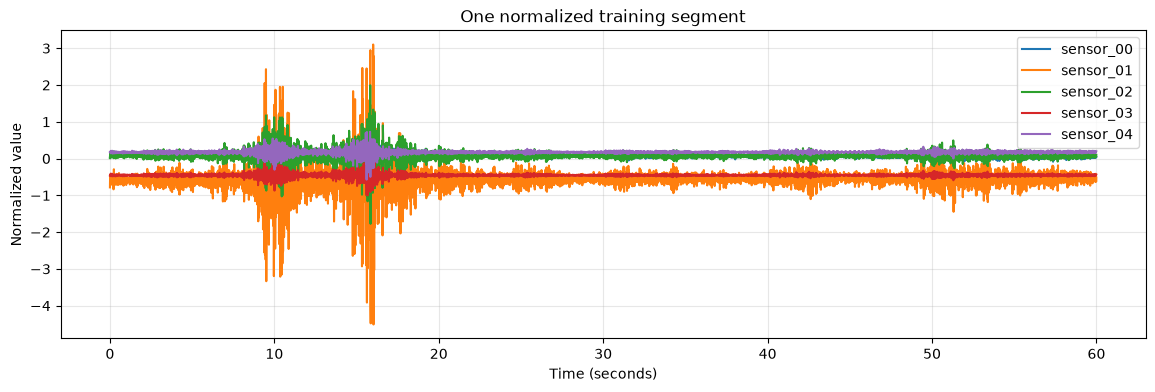

In [5]:
time_seconds = np.arange(6000) / 100.0
fig, ax = plt.subplots(figsize=(14, 4))
for sensor in range(5):
    ax.plot(time_seconds, x_train[0, :, sensor], label=f'sensor_{sensor:02d}')
ax.set(title='One normalized training segment', xlabel='Time (seconds)', ylabel='Normalized value')
ax.grid(alpha=0.3)
ax.legend()
plt.show()

## Build and train

Early stopping monitors validation loss. The test split is not passed to `fit()`.

In [6]:
tf.keras.backend.clear_session()
model = build_model(input_shape=(6000, 27), num_classes=17)
model.summary()

timestamp = datetime.now().strftime('%d-%m-%Y_%H-%M-%S')
ARTIFACT_DIR = ROOT / 'artifacts' / 'dataset_zip_dcnn_lstm_resnet' / timestamp
ARTIFACT_DIR.mkdir(parents=True, exist_ok=False)
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(ARTIFACT_DIR / 'best_model.keras', monitor='val_loss', mode='min', save_best_only=True),
]
history = model.fit(
    x_train, y_train, validation_data=(x_validation, y_validation),
    batch_size=BATCH_SIZE, epochs=EPOCHS, callbacks=callbacks,
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 6000, 27)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 3000, 64)  │     12,160 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 3000, 64)  │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 3000, 64)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 3000, 64)  │      4,160 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 3000, 64)  │          0 │ conv1d_1[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 3000, 64)  │     12,352 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 3000, 64)  │          0 │ conv1d_2[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 3000, 256) │     16,640 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 3000, 256) │     16,640 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 3000, 256) │          0 │ conv1d_3[0][0],   │
│                     │                   │            │ conv1d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 3000, 256) │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 3000, 64)  │     16,448 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 3000, 64)  │          0 │ conv1d_5[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 3000, 64)  │     12,352 │ activation_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_5        │ (None, 3000, 64)  │          0 │ conv1d_6[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 3000, 256) │     16,640 │ activation_5[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 3000, 256) │     65,792 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 3000, 256) │          0 │ conv1d_7[0][0],   │
│                     │                   │            │ conv1d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_6        │ (None, 3000, 256) │          0 │ add_1[0][0]     

 Total params: 508,689 (1.94 MB)

 Trainable params: 508,049 (1.94 MB)

 Non-trainable params: 640 (2.50 KB)

Epoch 1/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.1892 - loss: 2.9210 - val_accuracy: 0.3176 - val_loss: 2.5782
Epoch 2/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.3804 - loss: 1.9811 - val_accuracy: 0.4824 - val_loss: 2.1923
Epoch 3/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.5216 - loss: 1.4428 - val_accuracy: 0.5294 - val_loss: 1.7877
Epoch 4/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.6725 - loss: 1.0730 - val_accuracy: 0.5529 - val_loss: 1.6906
Epoch 5/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.7500 - loss: 0.7813 - val_accuracy: 0.5824 - val_loss: 1.7380
Epoch 6/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.7873 - loss: 0.6745 - val_accuracy: 0.6588 - val_loss: 1.7339
Epoch 7/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.8510 - loss: 0.4876 - val_accuracy: 0.5294 - val_loss: 1.9178
Epoch 8/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.8765 - loss: 0.4160 - val_accuracy: 0.5647 - v

KeyboardInterrupt: 

## Final test evaluation and reproducible outputs

In [ ]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, batch_size=BATCH_SIZE, verbose=0)
probabilities = model.predict(x_test, batch_size=BATCH_SIZE, verbose=0)
predictions = probabilities.argmax(axis=1)
report = classification_report(y_test, predictions, labels=np.arange(17), output_dict=True, zero_division=0)
matrix = confusion_matrix(y_test, predictions, labels=np.arange(17))

print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {test_accuracy:.4f}')
display(pd.DataFrame(report).T.round(3))
fig, ax = plt.subplots(figsize=(12, 12))
ConfusionMatrixDisplay(matrix, display_labels=np.arange(17)).plot(ax=ax, cmap='Blues', colorbar=False)
plt.show()

In [ ]:
model.save(ARTIFACT_DIR / 'final_model.keras')
pd.DataFrame(history.history).to_csv(ARTIFACT_DIR / 'history.csv', index=False)
pd.DataFrame(report).T.to_csv(ARTIFACT_DIR / 'classification_report.csv')
np.savetxt(ARTIFACT_DIR / 'confusion_matrix.csv', matrix, fmt='%d', delimiter=',')
np.savez(
    ARTIFACT_DIR / 'preprocessing.npz',
    sensor_mean=sensor_mean, sensor_std=sensor_std,
    train_indexes=SPLITS['train'], validation_indexes=SPLITS['validation'], test_indexes=SPLITS['test'],
)
experiment = {
    'archive': 'raw_data/dataset.zip',
    'stored_shape': list(inputs.shape),
    'model_input_shape': [6000, 27],
    'model_input_layout': 'time_samples x sensors',
    'num_classes': 17,
    'seed': SEED,
    'setup_split': {name: values.tolist() for name, values in SETUP_SPLIT.items()},
    'sensor_mean': sensor_mean.tolist(),
    'sensor_std': sensor_std.tolist(),
    'test_loss': float(test_loss),
    'test_accuracy': float(test_accuracy),
}
(ARTIFACT_DIR / 'experiment.json').write_text(json.dumps(experiment, indent=2), encoding='utf-8')
print('Saved to:', ARTIFACT_DIR)

In [ ]:
# Final train / validation / test metrics (macro average across classes)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def keras_split_metrics(split_name, X, y):
    probabilities = model.predict(X, batch_size=BATCH_SIZE, verbose=0)
    predictions = probabilities.argmax(axis=1)
    targets = np.asarray(y).reshape(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        targets, predictions, average='macro', zero_division=0
    )
    return {
        'split': split_name,
        'accuracy': accuracy_score(targets, predictions),
        'precision_macro': precision,
        'recall_macro': recall,
        'f1_macro': f1,
    }

split_metrics = pd.DataFrame([
    keras_split_metrics('train', x_train, y_train),
    keras_split_metrics('validation', x_validation, y_validation),
    keras_split_metrics('test', x_test, y_test),
]).set_index('split')
display(split_metrics.style.format('{:.2%}'))
split_metrics.to_csv(ARTIFACT_DIR / 'split_metrics.csv')